# Analysing the Space Race 🚀

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes every space mission since the start of the Space Race in 1957. We'll clean it and answer questions about the dominant organisations, costs, safety and the trends over time.

### Install & Import

In [1]:
%pip install iso3166 -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import calendar
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
from iso3166 import countries

%matplotlib inline
# Render Plotly charts as static images so they appear everywhere (incl. GitHub,
# which can't run interactive Plotly). Delete this line to get interactive charts.
pio.renderers.default = "png"
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)
pd.options.display.float_format = "{:,.2f}".format

### Load the Data

In [3]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* What are the column names?
* Are there any NaN values or duplicates?

In [4]:
df_data.shape

(4324, 9)

In [5]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [6]:
# Missing values per column
df_data.isna().sum()

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

In [7]:
# Duplicate rows
df_data.duplicated().sum()

np.int64(0)

## Data Cleaning

The two `Unnamed` columns are junk row-indexes. `Price` is text with commas and lots of gaps, and `Date` mixes two formats. We also derive **Year**, **Month**, a **Country** and its 3-letter **ISO** code (with a few manual fixes) for the maps.

In [8]:
df = df_data.loc[:, ~df_data.columns.str.contains("Unnamed")].copy()
df = df.drop_duplicates()

# Price -> number (strip the thousands separators). Most values are missing.
df["Price"] = pd.to_numeric(df["Price"].astype(str).str.replace(",", "", regex=False),
                            errors="coerce")

# Date -> datetime. Some rows have no time, so strip " UTC" and let pandas mix formats.
df["Date"] = pd.to_datetime(df["Date"].str.replace(" UTC", "", regex=False),
                            errors="coerce", format="mixed")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Country = the last part of the Location string, with a few manual corrections.
df["Country"] = df["Location"].str.split(",").str[-1].str.strip()
country_fixes = {
    "Russia": "Russian Federation", "New Mexico": "USA", "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran", "Pacific Missile Range Facility": "USA",
    "Barents Sea": "Russian Federation", "Gran Canaria": "USA",
}
df["Country"] = df["Country"].replace(country_fixes)

# 3-letter ISO code for the choropleth maps.
manual_iso = {"Iran": "IRN", "North Korea": "PRK", "South Korea": "KOR"}
def to_iso3(name):
    if name in manual_iso:
        return manual_iso[name]
    try:
        return countries.get(name).alpha3
    except KeyError:
        return None      # e.g. 'Pacific Ocean' (sea launches) has no country

df["ISO"] = df["Country"].apply(to_iso3)
df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Year,Month,Country,ISO
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,2020,8,USA,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,2020,8,China,CHN
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00,Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,2020,8,USA,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,2020,7,Kazakhstan,KAZ
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00,Atlas V 541 | Perseverance,StatusActive,145.00,Success,2020,7,USA,USA


## Descriptive Statistics

In [9]:
df.describe()

,Date,Price,Year,Month
count,4323,963.00,"4,323.00","4,323.00"
mean,1987-11-26 22:43:25.981957,153.92,"1,987.38",6.75
min,1957-10-04 19:28:00,5.30,"1,957.00",1.00
25%,1972-04-19 02:57:00,40.00,"1,972.00",4.00
50%,1984-12-14 20:40:00,62.00,"1,984.00",7.00
75%,2002-09-08 07:32:00,164.00,"2,002.00",10.00
max,2020-08-07 05:12:00,"5,000.00","2,020.00",12.00
std,NaN,288.57,18.07,3.42


In [10]:
print(f"Time span:       {int(df.Year.min())} - {int(df.Year.max())}")
print(f"Total missions:  {len(df):,}")
print(f"Organisations:   {df.Organisation.nunique()}")
print(f"Countries:       {df.Country.nunique()}")

Time span:       1957 - 2020
Total missions:  4,323
Organisations:   56
Countries:       16


# Number of Launches per Organisation

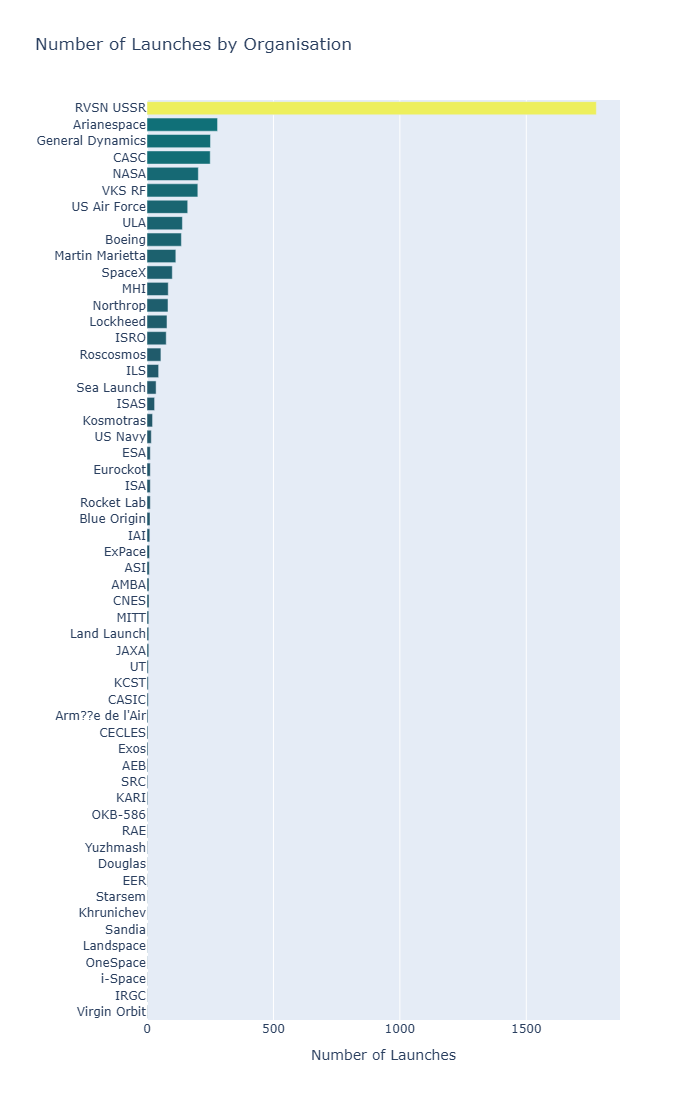

In [11]:
launches = df["Organisation"].value_counts()
fig = px.bar(x=launches.values, y=launches.index, orientation="h",
             color=launches.values, color_continuous_scale="Aggrnyl",
             labels={"x": "Number of Launches", "y": ""},
             title="Number of Launches by Organisation")
fig.update_layout(height=1100, coloraxis_showscale=False,
                  yaxis={"categoryorder": "total ascending"})
fig

> **Insight:** the Soviet **RVSN USSR** dwarfs everyone with ~1,780 launches — a legacy of the intense Cold-War launch cadence — followed by Europe's Arianespace and China's CASC.

# Active versus Retired Rockets

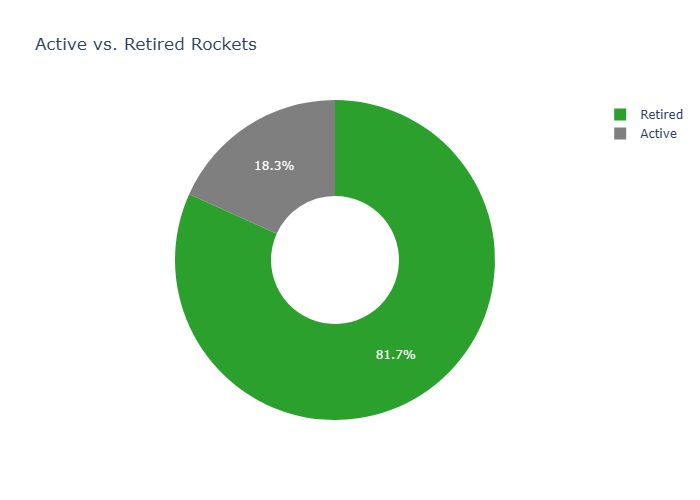

In [12]:
status = df["Rocket_Status"].value_counts()
fig = px.pie(names=status.index.str.replace("Status", ""), values=status.values,
             hole=0.4, title="Active vs. Retired Rockets",
             color_discrete_sequence=["#2ca02c", "#7f7f7f"])
fig

# Distribution of Mission Status

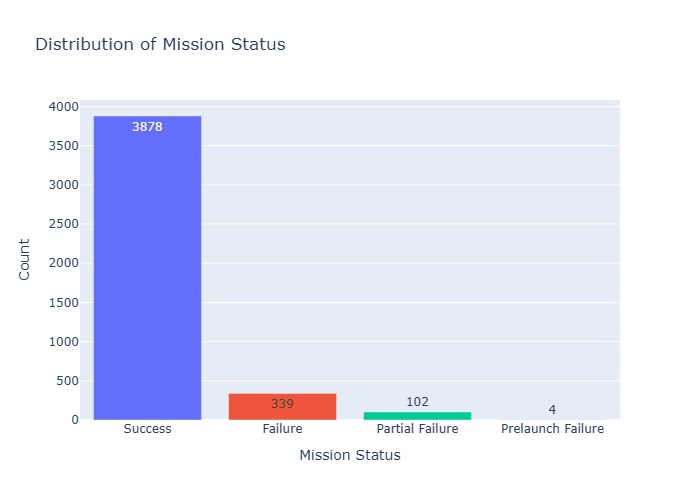

In [13]:
ms = df["Mission_Status"].value_counts()
fig = px.bar(x=ms.index, y=ms.values, color=ms.index, text=ms.values,
             labels={"x": "Mission Status", "y": "Count"},
             title="Distribution of Mission Status")
fig.update_layout(showlegend=False)
fig

# How Expensive are the Launches?

Price is in USD millions (many are missing).

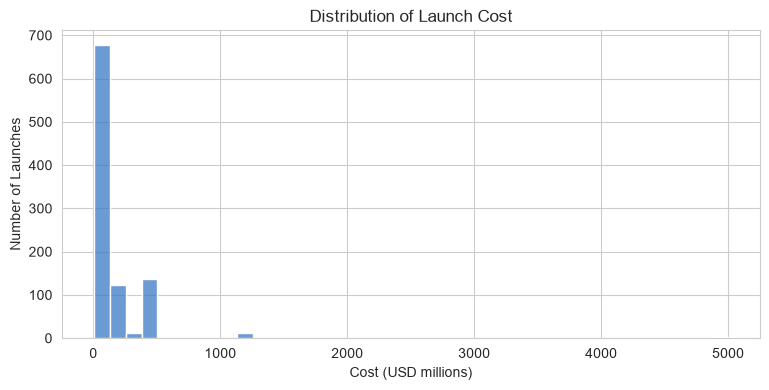

In [14]:
plt.figure()
sns.histplot(df["Price"].dropna(), bins=40, color="#3b78c3")
plt.title("Distribution of Launch Cost")
plt.xlabel("Cost (USD millions)"); plt.ylabel("Number of Launches")
plt.show()

# Launches by Country (Choropleth)

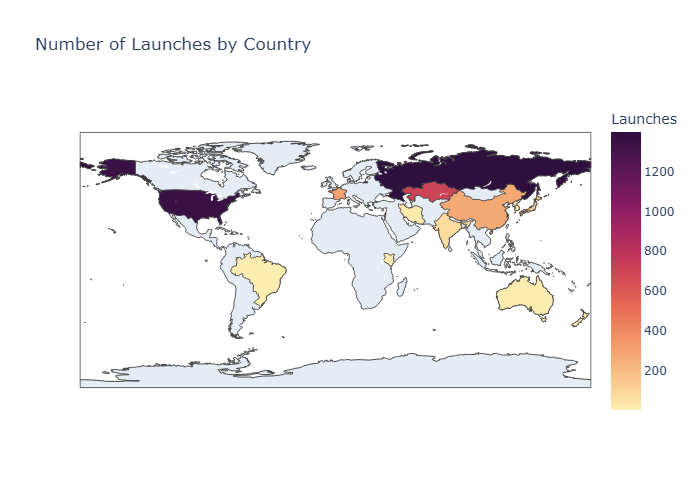

In [15]:
country_launches = (df.dropna(subset=["ISO"])
                      .groupby(["Country", "ISO"]).size().reset_index(name="Launches"))
fig = px.choropleth(country_launches, locations="ISO", color="Launches",
                    hover_name="Country", color_continuous_scale="matter",
                    title="Number of Launches by Country")
fig

# Mission Failures by Country (Choropleth)

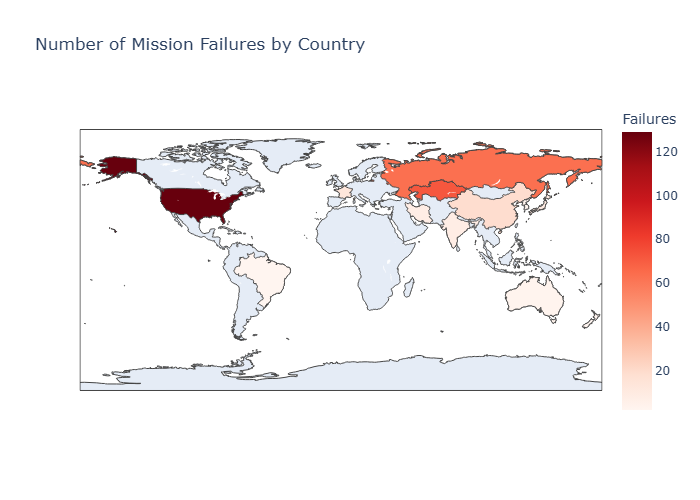

In [16]:
country_fail = (df[df.Mission_Status == "Failure"].dropna(subset=["ISO"])
                  .groupby(["Country", "ISO"]).size().reset_index(name="Failures"))
fig = px.choropleth(country_fail, locations="ISO", color="Failures",
                    hover_name="Country", color_continuous_scale="Reds",
                    title="Number of Mission Failures by Country")
fig

# Sunburst: Country → Organisation → Mission Status

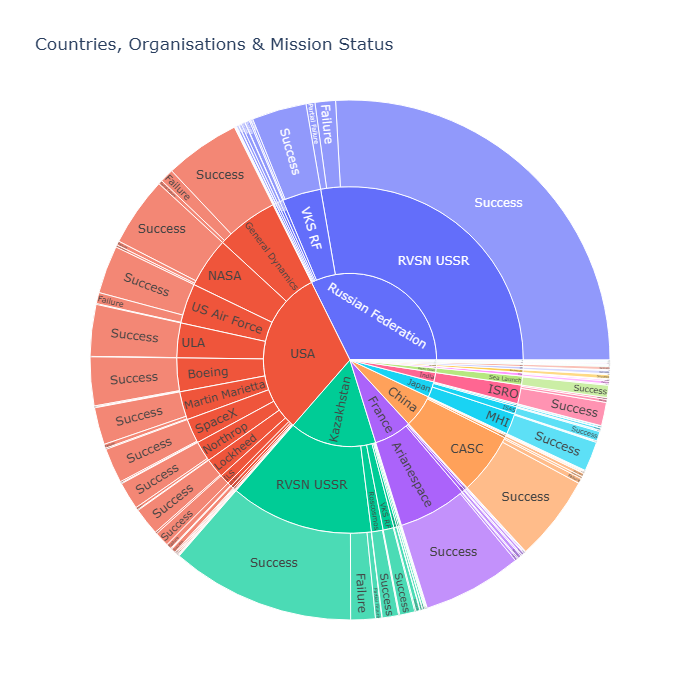

In [17]:
sun = (df.dropna(subset=["Country"])
         .groupby(["Country", "Organisation", "Mission_Status"]).size()
         .reset_index(name="Count"))
fig = px.sunburst(sun, path=["Country", "Organisation", "Mission_Status"],
                  values="Count", title="Countries, Organisations & Mission Status")
fig.update_layout(height=700)
fig

# Total Money Spent by Organisation

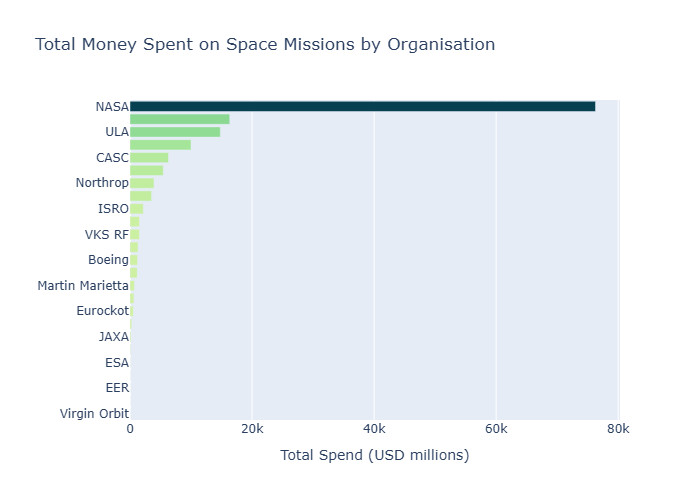

In [18]:
spend = df.groupby("Organisation")["Price"].sum().sort_values(ascending=False)
spend = spend[spend > 0]
fig = px.bar(x=spend.values, y=spend.index, orientation="h",
             color=spend.values, color_continuous_scale="Emrld",
             labels={"x": "Total Spend (USD millions)", "y": ""},
             title="Total Money Spent on Space Missions by Organisation")
fig.update_layout(coloraxis_showscale=False, yaxis={"categoryorder": "total ascending"})
fig

# Money Spent per Launch by Organisation

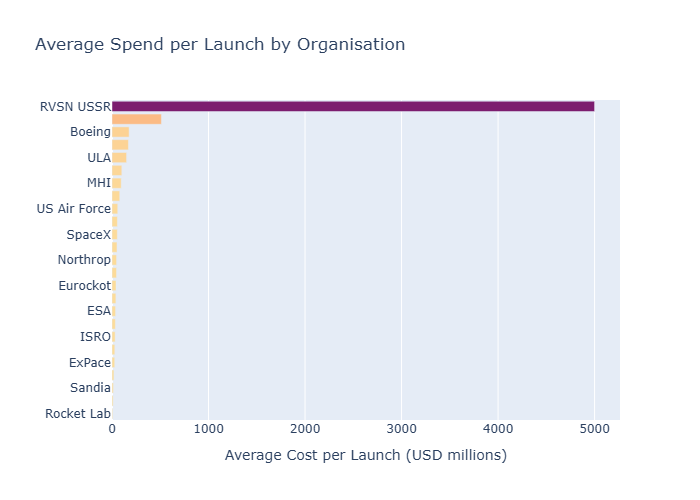

In [19]:
per_launch = df.groupby("Organisation")["Price"].mean().dropna().sort_values(ascending=False)
fig = px.bar(x=per_launch.values, y=per_launch.index, orientation="h",
             color=per_launch.values, color_continuous_scale="Sunsetdark",
             labels={"x": "Average Cost per Launch (USD millions)", "y": ""},
             title="Average Spend per Launch by Organisation")
fig.update_layout(coloraxis_showscale=False, yaxis={"categoryorder": "total ascending"})
fig

# Number of Launches per Year

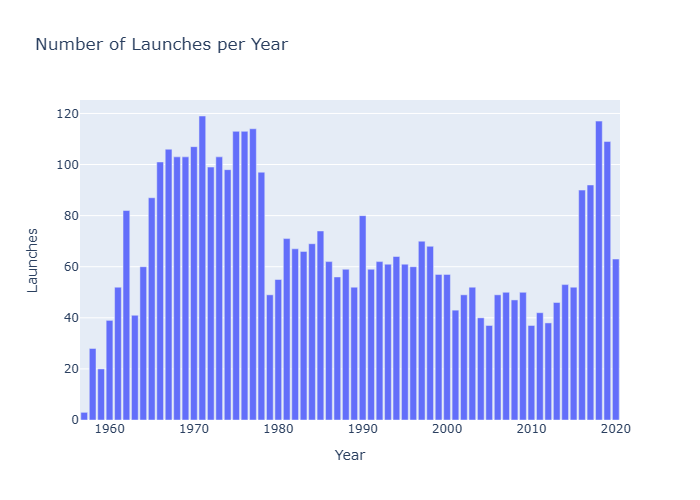

In [20]:
per_year = df["Year"].value_counts().sort_index()
fig = px.bar(x=per_year.index, y=per_year.values,
             labels={"x": "Year", "y": "Launches"},
             title="Number of Launches per Year")
fig

# Launches Month-on-Month (with 12-month rolling average)

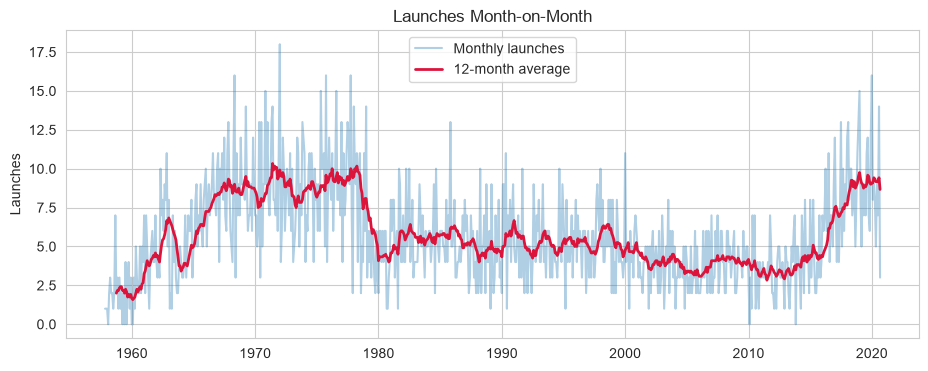

In [21]:
monthly = df.dropna(subset=["Date"]).set_index("Date").resample("ME").size()
rolling = monthly.rolling(window=12).mean()
plt.figure(figsize=(11, 4))
plt.plot(monthly.index, monthly.values, alpha=0.35, label="Monthly launches")
plt.plot(rolling.index, rolling.values, color="crimson", lw=2, label="12-month average")
plt.title("Launches Month-on-Month"); plt.ylabel("Launches"); plt.legend()
plt.show()

# Which Months are Most Popular for Launches?

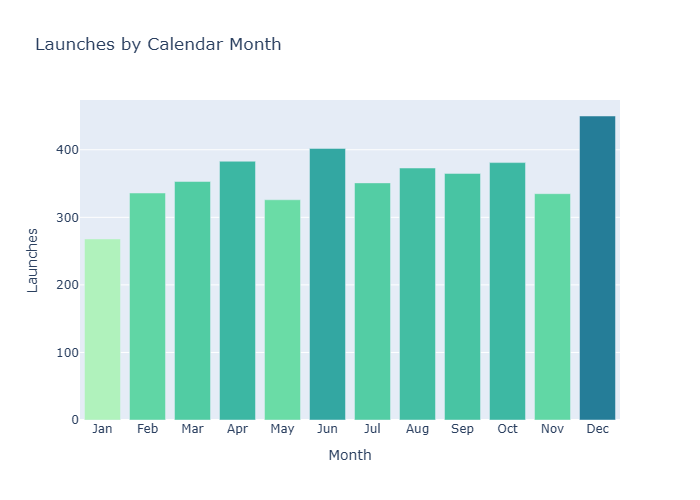

In [22]:
month_counts = df["Month"].value_counts().sort_index()
month_counts.index = [calendar.month_abbr[int(m)] for m in month_counts.index]
fig = px.bar(x=month_counts.index, y=month_counts.values,
             color=month_counts.values, color_continuous_scale="Tealgrn",
             labels={"x": "Month", "y": "Launches"},
             title="Launches by Calendar Month")
fig.update_layout(coloraxis_showscale=False)
fig

> **Insight:** **December** is the busiest launch month and **January** the quietest — agencies tend to clear their manifests before year-end.

# How has the Launch Price varied Over Time?

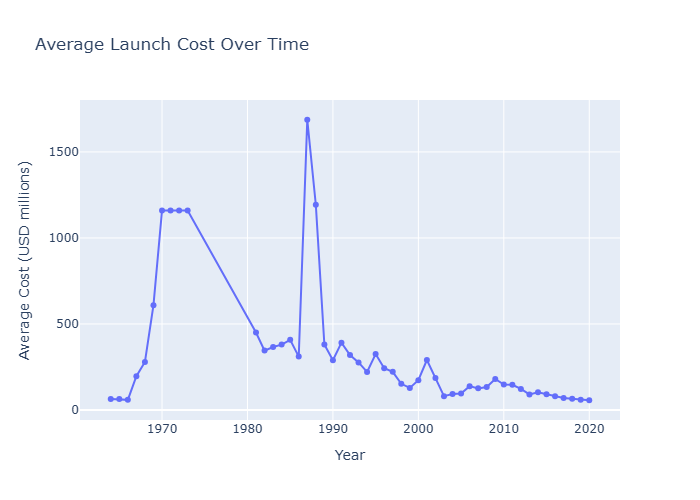

In [23]:
price_year = df.groupby("Year")["Price"].mean().dropna()
fig = px.line(x=price_year.index, y=price_year.values, markers=True,
              labels={"x": "Year", "y": "Average Cost (USD millions)"},
              title="Average Launch Cost Over Time")
fig

# Launches Over Time — Top 10 Organisations

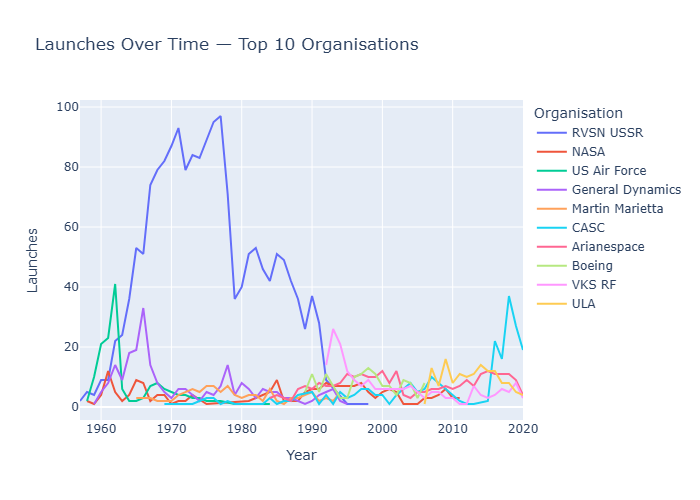

In [24]:
top10 = df["Organisation"].value_counts().head(10).index
top_over_time = (df[df.Organisation.isin(top10)]
                   .groupby(["Year", "Organisation"]).size().reset_index(name="Launches"))
fig = px.line(top_over_time, x="Year", y="Launches", color="Organisation",
              title="Launches Over Time — Top 10 Organisations")
fig

# Cold War: USA vs USSR

The Cold War ran from the start of the dataset to 1991. We count former Soviet republics (Kazakhstan / Baikonur) as USSR.

## Total Launches: USSR vs USA

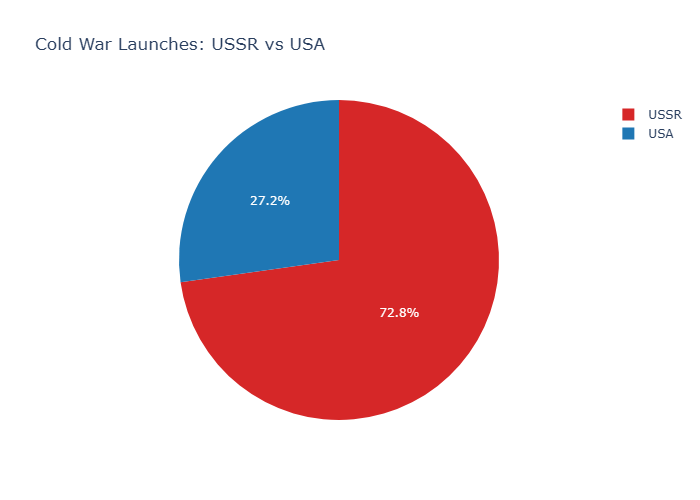

In [25]:
cold_war = df[df.Year <= 1991].copy()
cold_war["Superpower"] = cold_war["Country"].map(
    {"Russian Federation": "USSR", "Kazakhstan": "USSR", "USA": "USA"})
sp = cold_war.dropna(subset=["Superpower"])["Superpower"].value_counts()
fig = px.pie(names=sp.index, values=sp.values, title="Cold War Launches: USSR vs USA",
             color=sp.index, color_discrete_map={"USSR": "#d62728", "USA": "#1f77b4"})
fig

## Launches Year-on-Year: USSR vs USA

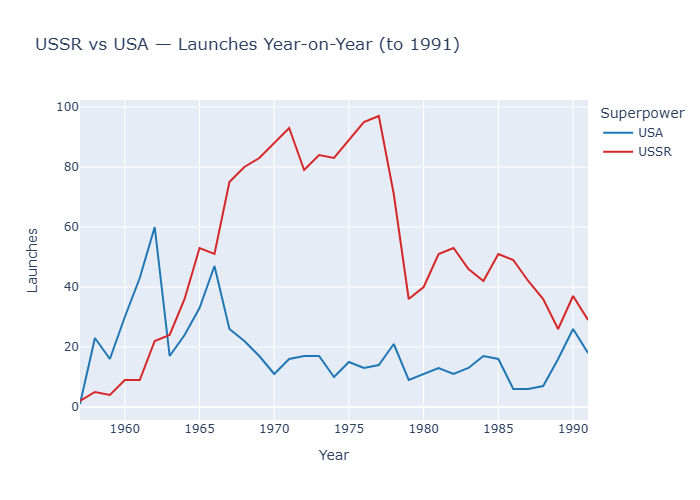

In [26]:
yoy = (cold_war.dropna(subset=["Superpower"])
         .groupby(["Year", "Superpower"]).size().reset_index(name="Launches"))
fig = px.line(yoy, x="Year", y="Launches", color="Superpower",
              color_discrete_map={"USSR": "#d62728", "USA": "#1f77b4"},
              title="USSR vs USA — Launches Year-on-Year (to 1991)")
fig

## Total Mission Failures Year-on-Year

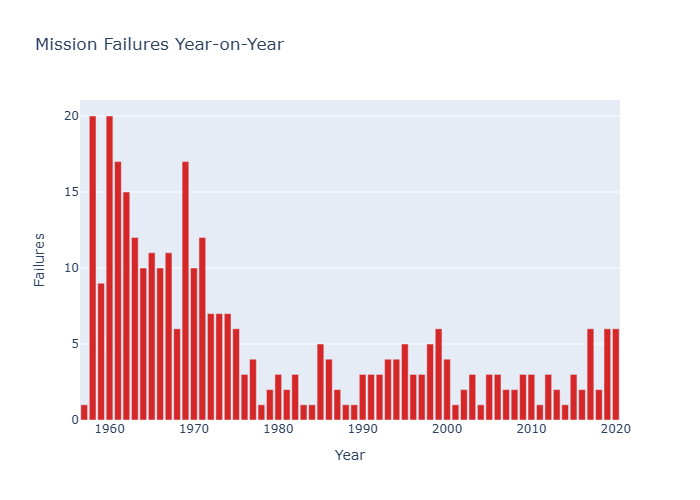

In [27]:
fail_year = df[df.Mission_Status == "Failure"].groupby("Year").size()
fig = px.bar(x=fail_year.index, y=fail_year.values, color_discrete_sequence=["#d62728"],
             labels={"x": "Year", "y": "Failures"}, title="Mission Failures Year-on-Year")
fig

## Percentage of Failures Over Time

Have missions gotten safer?

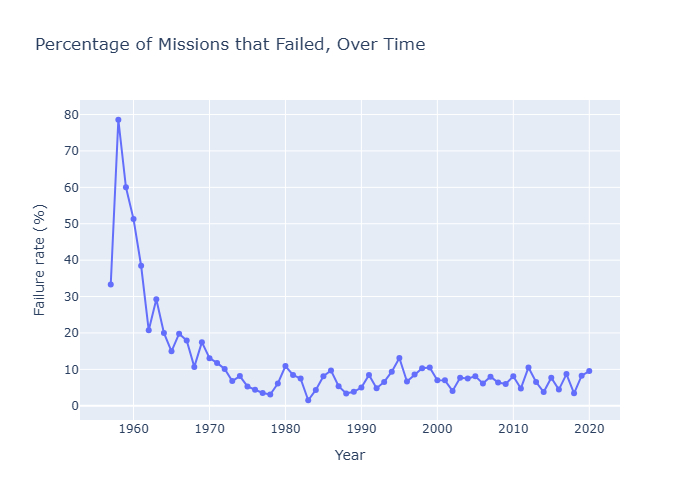

In [28]:
total_year = df.groupby("Year").size()
not_success = df[df.Mission_Status != "Success"].groupby("Year").size()
pct_fail = (not_success / total_year * 100).reindex(total_year.index).fillna(0)
fig = px.line(x=pct_fail.index, y=pct_fail.values, markers=True,
              labels={"x": "Year", "y": "Failure rate (%)"},
              title="Percentage of Missions that Failed, Over Time")
fig

> **Insight:** the early years were brutal — **1958** saw a ~73% failure rate. The failure rate fell steadily as the technology matured and now sits in the low single digits.

# Which Country Led Each Year?

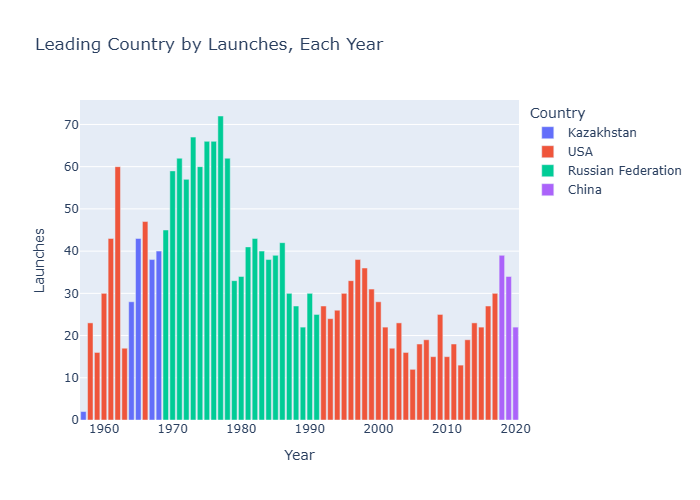

In [29]:
by_country_year = df.groupby(["Year", "Country"]).size().reset_index(name="Launches")
leaders = by_country_year.loc[by_country_year.groupby("Year")["Launches"].idxmax()]
fig = px.bar(leaders, x="Year", y="Launches", color="Country",
             title="Leading Country by Launches, Each Year")
fig

In [30]:
# Number of years each country was in the lead
leaders['Country'].value_counts()

Country
USA                   33
Russian Federation    23
Kazakhstan             5
China                  3
Name: count, dtype: int64

# Which Organisation Led Each Year?

Who dominated the 1970s-80s vs 2018-2020?

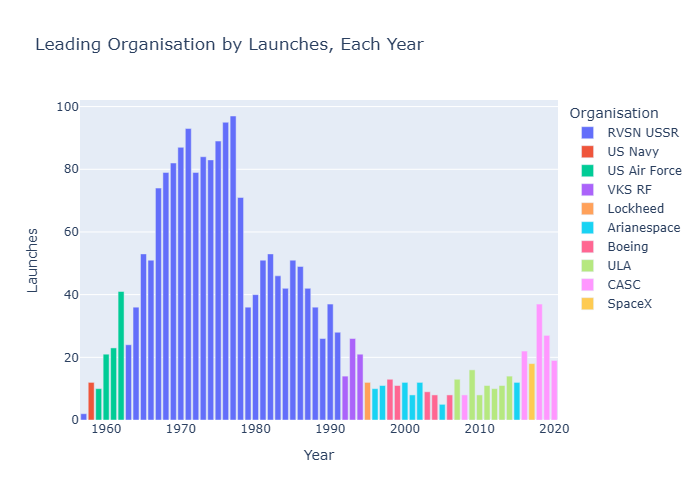

In [31]:
by_org_year = df.groupby(["Year", "Organisation"]).size().reset_index(name="Launches")
org_leaders = by_org_year.loc[by_org_year.groupby("Year")["Launches"].idxmax()]
fig = px.bar(org_leaders, x="Year", y="Launches", color="Organisation",
             title="Leading Organisation by Launches, Each Year")
fig

# Key Insights 🛰️

* **The USSR won the launch race.** Its RVSN USSR is by far the most prolific launcher, and the USSR out-launched the USA through most of the Cold War.
* **The USA led the most *years* overall** (32), but Russia/USSR is close (24), and **China (CASC) has taken the lead most recently** (2018-2020).
* **Space got much safer.** Failure rates fell from ~70% in the late 1950s to low single digits today.
* **December is peak launch season**, January the quietest.
* **NASA has spent the most in total**, while a handful of heavy-lift missions push the highest *per-launch* costs.